#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully")

Libraries imported successfully


#Load Datasets

In [2]:
df = pd.read_csv("creditcard.csv")
print("Dataset saved successfully!")

Dataset saved successfully!


#Checking the datasets information

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176396 entries, 0 to 176395
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    176396 non-null  float64
 1   V1      176396 non-null  float64
 2   V2      176396 non-null  float64
 3   V3      176396 non-null  float64
 4   V4      176396 non-null  float64
 5   V5      176396 non-null  float64
 6   V6      176396 non-null  float64
 7   V7      176396 non-null  float64
 8   V8      176396 non-null  float64
 9   V9      176396 non-null  float64
 10  V10     176395 non-null  float64
 11  V11     176395 non-null  float64
 12  V12     176395 non-null  float64
 13  V13     176395 non-null  float64
 14  V14     176395 non-null  float64
 15  V15     176395 non-null  float64
 16  V16     176395 non-null  float64
 17  V17     176395 non-null  float64
 18  V18     176395 non-null  float64
 19  V19     176395 non-null  float64
 20  V20     176395 non-null  float64
 21  V21     17

In [4]:
df.shape

(176396, 31)

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,176396.000000,...,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000,176395.000000
mean,62982.145701,-0.154506,0.030861,0.455517,0.105809,-0.164180,0.056130,-0.075411,0.028465,0.016747,...,-0.025204,-0.075271,-0.020898,0.008065,0.085239,0.011061,0.002433,0.002292,87.864992,0.002052
std,29342.892261,1.864762,1.612565,1.401140,1.378648,1.350417,1.301105,1.214113,1.228852,1.148828,...,0.742832,0.673261,0.594096,0.600062,0.470995,0.490002,0.392008,0.306107,246.830642,0.045255
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,41793.750000,-0.980646,-0.550846,-0.118789,-0.759179,-0.820666,-0.695054,-0.585255,-0.166800,-0.660642,...,-0.229846,-0.544525,-0.169666,-0.334266,-0.206132,-0.330606,-0.065351,-0.031394,5.520000,0.000000
50%,62028.000000,-0.159085,0.101641,0.597976,0.111055,-0.216066,-0.206152,-0.028765,0.053284,-0.078358,...,-0.051891,-0.059415,-0.034394,0.058285,0.129175,-0.059486,0.008157,0.020614,22.000000,0.000000
75%,79933.000000,1.190938,0.796824,1.282814,0.925997,0.393076,0.447622,0.469102,0.347519,0.637736,...,0.133506,0.377058,0.102684,0.417207,0.396081,0.270273,0.089670,0.078228,77.600000,0.000000
max,122746.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


#Checking the missing Values

In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
V10,1
V11,1
V12,1
V13,1
V14,1
V15,1
V16,1
V17,1
V18,1
V19,1


In [7]:
# Remove rows with missing values
df = df.dropna()

In [8]:
df.shape
df.isnull().sum().sum()

np.int64(0)

#Checking and Dropping the duplicates

In [9]:
df.duplicated().sum()
df = df.drop_duplicates()

#Checking the class distribution

In [10]:
df['Class'].value_counts()

,count
Class,
0.0,175384
1.0,344


#Visualizing the class distribution

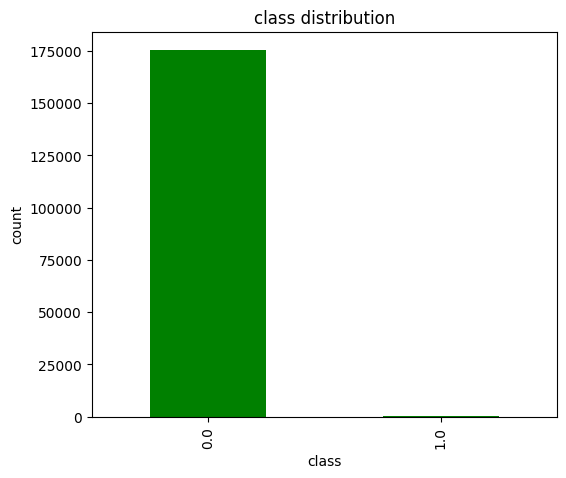

In [11]:
plt.figure(figsize=(6,5))
df['Class'].value_counts().plot(kind = 'bar', color = 'green')
plt.title("class distribution")
plt.xlabel("class")
plt.ylabel("count")
plt.savefig("class_distribution.png")
plt.show()

#Separating Features and Target

In [12]:
x = df.drop("Class", axis = 1)
y = df["Class"]
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (175728, 30)
Target shape: (175728,)


#Train-Test Split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)

Training samples: (140582, 30)
Testing samples: (35146, 30)


#Training the baseline model

In [14]:
rf_model = RandomForestClassifier(
    random_state = 42,
)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

#Make Prediction

In [15]:
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)

#Evaluating the baseline model

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")


Accuracy: 0.9994
Precision: 0.9273
Recall: 0.7391
F1: 0.8226


#Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[35073     4]
 [   18    51]]


#Generating Prediction probability

In [18]:
y_prob = rf_model.predict_proba(x_test)[:, 1]
print(y_prob.shape)

(35146,)


#Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     35077
         1.0       0.93      0.74      0.82        69

    accuracy                           1.00     35146
   macro avg       0.96      0.87      0.91     35146
weighted avg       1.00      1.00      1.00     35146



#ROC-AUC Score

In [20]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9036


#Creating Custom Function for the ROC

In [21]:
def plot_roc_curve(y_true, y_prob):
  fpr, tpr, thresholds = roc_curve(y_true , y_prob)
  plt.figure(figsize=(6,5))
  plt.plot(fpr, tpr, color = 'orange', label = "ROC Curve" )
  plt.plot([0,1], [0,1], linestyle = "--", label = "Random Classifier")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend()
  plt.show()

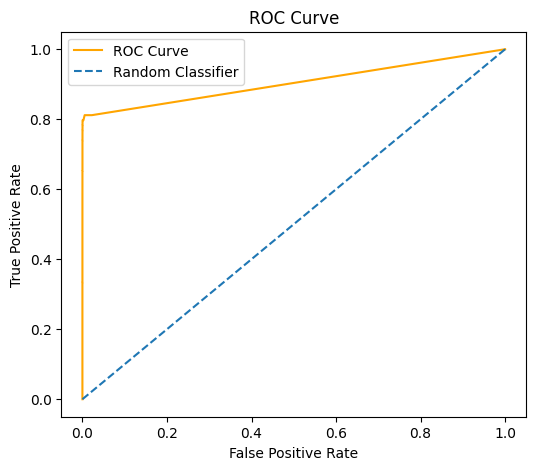

<Figure size 640x480 with 0 Axes>

In [31]:
plot_roc_curve(y_test, y_prob)
plt.savefig("roc_curve.png")

#Creating a Precision Recall Curve Function

In [23]:
def plot_precision_recall_curve(y_true, y_prob):
  precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
  plt.figure(figsize = (6,5))
  plt.plot(recall, precision, color = "purple")
  plt.xlabel("recall")
  plt.ylabel("precision")
  plt.title("precision-recall curve")
  plt.show()

Precision Fall Curve

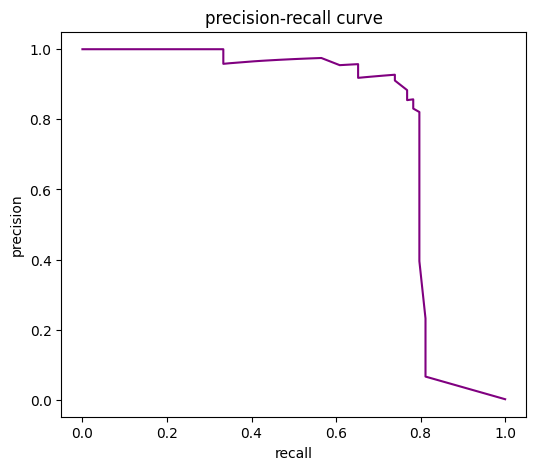

<Figure size 640x480 with 0 Axes>

In [30]:
plot_precision_recall_curve(y_test, y_prob)
plt.savefig("precision_fall_curve.png")

#Average Precision Score

In [25]:
ap_score = average_precision_score(y_test, y_prob)
print(f"Average Precision Score: {ap_score:.4f}")

Average Precision Score: 0.7752


#Analyzing Precision Recall Tradeoff at different threshold

In [26]:
thresholds = [0.3,0.5,0.7,0.9]
for threshold in thresholds:
  y_pred_threshold = (y_prob >= threshold).astype(int)
  precision = precision_score(y_test, y_pred_threshold)
  recall = recall_score(y_test, y_pred_threshold)
  f1 = f1_score(y_test, y_pred_threshold)
  print(f"\nThreshold: {threshold}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1: {f1:.4f}")


Threshold: 0.3
Precision: 0.8308
Recall: 0.7826
F1: 0.8060

Threshold: 0.5
Precision: 0.9273
Recall: 0.7391
F1: 0.8226

Threshold: 0.7
Precision: 0.9565
Recall: 0.6377
F1: 0.7652

Threshold: 0.9
Precision: 0.9600
Recall: 0.3478
F1: 0.5106


#Comparing Macro, Micro, and weighted F1

In [27]:
macro_f1 = f1_score(y_test, y_pred, average = 'macro')
micro_f1 = f1_score(y_test, y_pred, average = 'micro')
weighted_f1 = f1_score(y_test, y_pred, average = "weighted")
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Micro F1 : {micro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Macro F1 : 0.9111
Micro F1 : 0.9994
Weighted F1: 0.9993


#Evaluation Summary

In [29]:
print("=" * 50)
print("Evaluation Summary")
print("=" * 50)

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision_score(y_test, y_pred):.4f}")
print(f"Recall              : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score            : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"Average Precision   : {ap_score:.4f}")
print(f"Macro F1            : {macro_f1:.4f}")
print(f"Micro F1            : {micro_f1:.4f}")
print(f"Weighted F1         : {weighted_f1:.4f}")

Evaluation Summary
Accuracy            : 0.9994
Precision           : 0.9273
Recall              : 0.7391
F1 Score            : 0.8226
ROC-AUC             : 0.9036
Average Precision   : 0.7752
Macro F1            : 0.9111
Micro F1            : 0.9994
Weighted F1         : 0.9993


#Business Interpretation

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of all transactions. Therefore, accuracy alone is not a reliable evaluation metric because a model can achieve high accuracy by predicting most transactions as genuine. The Precision-Recall curve provides a better understanding of the model's ability to detect fraud. In fraud detection, recall is particularly important because failing to identify fraudulent transactions can lead to financial losses. However, increasing recall often reduces precision by generating more false alarms. The threshold analysis demonstrated this trade-off. Macro, micro, and weighted F1-scores provide different perspectives on performance, with weighted F1 accounting for the class imbalance. Overall, the Precision-Recall curve, Recall, and Weighted F1-score are the most suitable metrics for evaluating this fraud detection model.